Title: Cyber Threat Dataset: Network, Text & Relation
Author: Philani Kubeka, 35048506
Problem statement: 
Dataset: 

Setup and Reproducability

In [3]:
import os, re, json, random, time, copy, sys
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve,
    auc, precision_recall_curve, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, log_loss)
%matplotlib inline
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, ART, OUT = ROOT / "data" / "raw", ROOT / "artifacts", ROOT / "outputs"
FIG = OUT / "figures"
for d in (ART, FIG): d.mkdir(parents=True, exist_ok=True)
print("python", sys.version.split()[0], "| torch", torch.__version__, "| device", DEVICE)


python 3.13.7 | torch 2.13.0+cpu | device cpu


Data loading and Inspection

In [ ]:
for f in sorted(DATA_DIR.rglob("*")):
    if f.suffix.lower() == ".csv":
        cols = list(pd.read_csv(f, nrows=2).columns)
        print(f.relative_to(DATA_DIR), f.stat().st_size // 1024, "KB ->", cols)
    elif f.suffix.lower() == ".json":
        print(f.relative_to(DATA_DIR), f.stat().st_size // 1024, "KB (json)")

Cyber-Threat-Intelligence-Custom-Data_new_processed.csv 563 KB -> ['id', 'text', 'relations', 'diagnosis', 'solutions', 'id_1', 'label_1', 'start_offset_1', 'end_offset_1', 'id_2', 'label_2', 'start_offset_2', 'end_offset_2', 'id_3', 'label_3', 'start_offset_3', 'end_offset_3']
cyber-threat-intelligence-splited_test.csv 386 KB -> ['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']
cyber-threat-intelligence-splited_train.csv 1840 KB -> ['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']
cyber-threat-intelligence-splited_validate.csv 395 KB -> ['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']
cyber-threat-intelligence_all.csv 5291 KB -> ['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']


In [5]:
DATA_FILE = DATA_DIR / "all.jsonl"
rows = []
with open(DATA_FILE, encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        for ent in rec["entities"]:          # one row per annotated entity
            rows.append({"text": rec["text"], "label": ent["label"],
                         "start_offset": ent["start_offset"], "end_offset": ent["end_offset"]})
raw = pd.DataFrame(rows)
raw["label"] = raw["label"].replace({"Infrastucture": "infrastructure"})   # typo in the dataset
print(raw.shape); display(raw.head()); print(raw["label"].value_counts())
# ---------------- CONFIG: the only place you rename columns / switch modes ----------------
TEXT_COL = "text"
LABEL_COL = "label"
START_COL, END_COL = "start_offset", "end_offset"
USE_SPAN = True # True = classify the highlighted entity WITH its context; False = whole text
CONTEXT_CHARS = 60 # characters of context kept on each side of the entity
MIN_PER_CLASS = 10 # drop labels rarer than this (cannot be split/evaluated reliably)


(12679, 4)


,text,label,start_offset,end_offset
0,This post is also available in: 日本語 (Japa...,malware,288,300
1,This post is also available in: 日本語 (Japa...,malware,53,63
2,This post is also available in: 日本語 (Japa...,malware,342,352
3,The attack vector is very basic and repeats it...,attack-pattern,69,115
4,The first known campaign was launched by Crim...,TIME,55,68


label
location          3137
malware           1750
attack-pattern    1380
SOFTWARE          1246
identity          1160
threat-actor       870
FILEPATH           500
TIME               486
tools              454
SHA2               453
vulnerability      296
IPV4               195
DOMAIN             182
SHA1               171
URL                140
campaign           104
MD5                 59
infrastructure      38
REGISTRYKEY         34
EMAIL               24
Name: count, dtype: int64


Preprocessing

In [6]:
df = raw.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
df[TEXT_COL] = df[TEXT_COL].astype(str)
def make_input(t, s=None, e=None):
    """Same function is reused by the API, so training and serving see identical text."""
    t = str(t)
    if USE_SPAN and s is not None and e is not None and not pd.isna(s) and not pd.isna(e):
        s, e = int(s), int(e)
        left, right = t[max(0, s - CONTEXT_CHARS):s], t[e:e + CONTEXT_CHARS]
        return f"{left} entstart {t[s:e]} entend {right}"
    return t

if USE_SPAN:
    df["input_text"] = [make_input(t, s, e)
    for t, s, e in zip(df[TEXT_COL], df[START_COL], df[END_COL])]
else:
    df["input_text"] = [make_input(t) for t in df[TEXT_COL]]

df["input_text"] = df["input_text"].str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["input_text"].str.len() > 0]
n0 = len(df)
df = df.drop_duplicates(subset=["input_text", LABEL_COL])
conflict = df.groupby("input_text")[LABEL_COL].transform("nunique") > 1
print(f"exact duplicates removed: {n0 - len(df)} | "
    f"rows with conflicting labels removed: {conflict.sum()}")
df = df[~conflict]
vc = df[LABEL_COL].value_counts()
print("labels dropped as too rare:", dict(vc[vc < MIN_PER_CLASS]))
df = df[df[LABEL_COL].isin(vc[vc >= MIN_PER_CLASS].index)].reset_index(drop=True)
class_names = sorted(df[LABEL_COL].unique())
label2id = {c: i for i, c in enumerate(class_names)}
df["y"] = df[LABEL_COL].map(label2id)
n_classes = len(class_names)
print(n_classes, "classes:", class_names, "| rows:", len(df))
display(df[["input_text", LABEL_COL, "y"]].sample(5, random_state=SEED))

exact duplicates removed: 1301 | rows with conflicting labels removed: 70
labels dropped as too rare: {}
20 classes: ['DOMAIN', 'EMAIL', 'FILEPATH', 'IPV4', 'MD5', 'REGISTRYKEY', 'SHA1', 'SHA2', 'SOFTWARE', 'TIME', 'URL', 'attack-pattern', 'campaign', 'identity', 'infrastructure', 'location', 'malware', 'threat-actor', 'tools', 'vulnerability'] | rows: 11308


,input_text,label,y
6977,entstart RemoteUtilities entend Analysis,tools,18
8965,outine has been associated with TICK’s weapons...,location,15
9651,"Take, for example, the following sample: entst...",SHA2,7
7972,the combination of techniques used for deploym...,location,15
10428,Threat actors like Tropic Trooper entstart can...,location,15


Data analysis

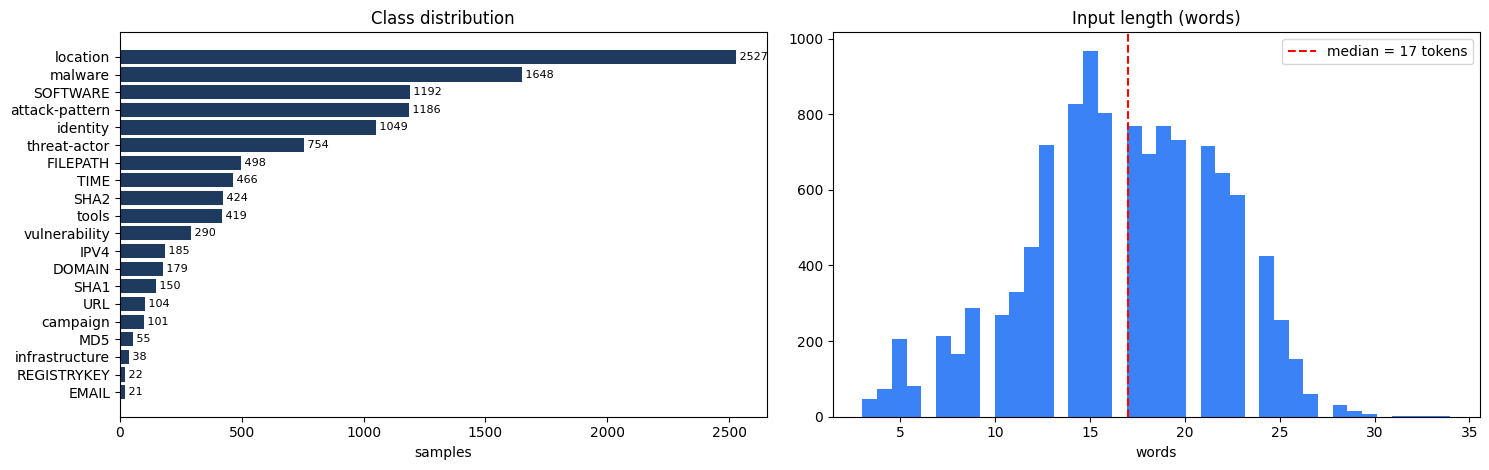

imbalance ratio (largest / smallest class): 120.3
[DOMAIN] has expanded to 48 gov.ua domains and one Ukranian company ( entstart motorsich[.]com entend ) that builds engines for airplanes and helicopters.
[EMAIL] and have WhoIs records associated with the e-mail address “ entstart ladomfichisi1987@mail.ru entend ”.
[FILEPATH] If entstart user32.dll entend were encrypted and unusable, it would be a problem.
[IPV4] All of the domains currently resolve to entstart 151.248.115.146 entend , a Russian IP address and have WhoIs records associated wit
[MD5] tly Palo Alto Networks discovered a backdoor program ( md5: entstart b826fb1253a52a3b53afa3b7543d7694 entend , sha256: 6bedd1b0716fe7632188932451f7529
[REGISTRYKEY] es the file extension through modification of the registry ( entstart HKCU\Software\Microsoft\Windows\CurrentVersion\Explorer\Advanced\HideFileExt ent


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
vc = df[LABEL_COL].value_counts()
axes[0].barh(vc.index[::-1], vc.values[::-1], color="#1F3A5F")
for i, v in enumerate(vc.values[::-1]): axes[0].text(v, i, f" {v}", va="center", fontsize=8)
axes[0].set_title("Class distribution"); axes[0].set_xlabel("samples")
lens = df["input_text"].str.split().str.len()
axes[1].hist(lens, bins=40, color="#3B82F6")
axes[1].axvline(lens.median(), color="red", ls="--", label=f"median = {lens.median():.0f} tokens")
axes[1].set_title("Input length (words)"); axes[1].set_xlabel("words"); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / "eda_overview.png", dpi=150); plt.show()
print("imbalance ratio (largest / smallest class): %.1f" % (vc.max() / vc.min()))
for c in class_names[:6]:
    print(f"[{c}]", df.loc[df[LABEL_COL] == c, "input_text"].iloc[0][:150])

Train/Validation/Test split

{'train': '8065 (71.3%)', 'val': '1634 (14.4%)', 'test': '1609 (14.2%)'}


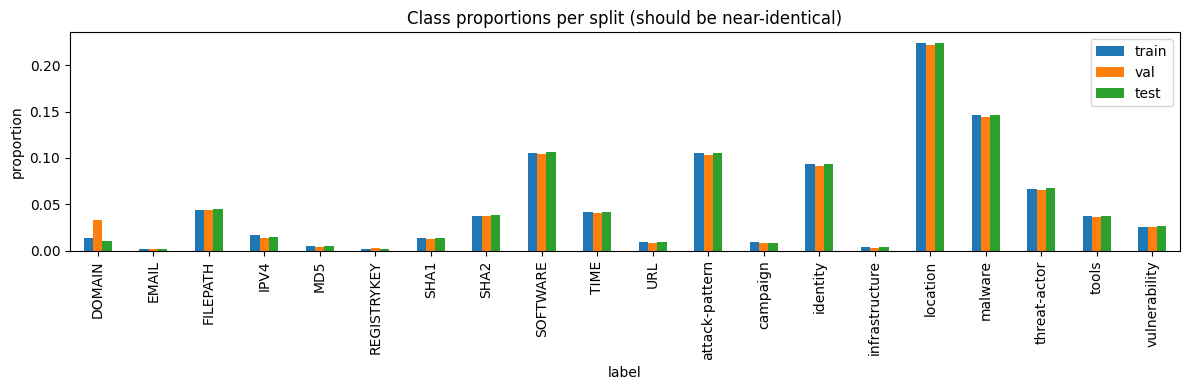

In [8]:
groups = df[TEXT_COL].factorize()[0] # rows from the same text share a group
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf.split(df, df["y"], groups))
trainval = df.iloc[trainval_idx]
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_i, va_i = next(sgkf2.split(trainval, trainval["y"], groups[trainval_idx]))
train_df, val_df, test_df = trainval.iloc[tr_i], trainval.iloc[va_i], df.iloc[test_idx]
for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    assert set(part["y"]) == set(range(n_classes)), f"{name} is missing a class: raise MIN_PER_CLASS"
assert not (set(train_df[TEXT_COL]) & set(test_df[TEXT_COL])), "text leakage train/test"
assert not (set(train_df[TEXT_COL]) & set(val_df[TEXT_COL])), "text leakage train/val"
print({k: f"{len(v)} ({len(v)/len(df):.1%})" for k, v in
    dict(train=train_df, val=val_df, test=test_df).items()})
dist = pd.DataFrame({n: p[LABEL_COL].value_counts(normalize=True)
    for n, p in [("train", train_df), ("val", val_df), ("test", test_df)]})
dist.plot.bar(figsize=(12, 4), title="Class proportions per split (should be near-identical)")
plt.ylabel("proportion"); plt.tight_layout()
plt.savefig(FIG / "split_distribution.png", dpi=150); plt.show()

Tokenisation and Dataloaders

In [9]:
def tokenize(t):
    return re.findall(r"[a-z0-9_]+|[^\sa-z0-9_]", t.lower())
counter = Counter(tok for t in train_df["input_text"] for tok in tokenize(t)) # TRAIN ONLY: no leakage
MIN_FREQ = 2
itos = ["<pad>", "<unk>"] + [w for w, c in counter.most_common() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
lens_tok = [len(tokenize(t)) for t in train_df["input_text"]]
MAX_LEN = int(min(max(np.percentile(lens_tok, 95), 16), 160))
print("vocab size:", len(itos), "| MAX_LEN:", MAX_LEN)
def encode(t):
    ids = [stoi.get(w, 1) for w in tokenize(t)][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))
class ThreatDS(Dataset):
    def __init__(self, d):
        self.X = torch.tensor([encode(t) for t in d["input_text"]], dtype=torch.long)
        self.y = torch.tensor(d["y"].values, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]
train_ds, val_ds, test_ds = ThreatDS(train_df), ThreatDS(val_df), ThreatDS(test_df)
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
train_eval_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

vocab size: 6329 | MAX_LEN: 36


Model Architecture

In [10]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, n_classes, emb_dim=128, hidden=128, layers=2,
    dropout=0.4, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=layers, batch_first=True, bidirectional=True,
        dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden * 4, 128) # [max-pool | mean-pool] of 2*hidden each
        self.fc2 = nn.Linear(128, n_classes) # raw logits; softmax is inside the loss
    def forward(self, x):
        mask = (x != self.pad_idx).unsqueeze(-1) # B,T,1
        lengths = mask.squeeze(-1).sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(self.drop(self.emb(x)), lengths,
        batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        mx = out.masked_fill(~mask, -1e9).max(dim=1).values
        mean = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        h = torch.cat([mx, mean], dim=1)
        return self.fc2(self.drop(torch.relu(self.fc1(self.drop(h)))))
HP = dict(emb_dim=128, hidden=128, layers=2, dropout=0.4)
counts = np.bincount(train_df["y"], minlength=n_classes)
class_w = torch.tensor(len(train_df) / (n_classes * counts), dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_w) # inverse-frequency weights for imbalance
tmp = BiLSTMClassifier(len(itos), n_classes, **HP)
print(tmp); print("trainable parameters:", sum(p.numel() for p in tmp.parameters() if p.requires_grad))

BiLSTMClassifier(
  (emb): Embedding(6329, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (drop): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=20, bias=True)
)
trainable parameters: 1537812


Evaluation Metrics

In [11]:
def compute_metrics(y_true, y_prob, loss):
    y_prob = np.asarray(y_prob, dtype="float64")
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True) # exact row sums for sklearn
    y_pred = y_prob.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    try:
        auc_roc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro",
        labels=np.arange(y_prob.shape[1]))
    except ValueError:
        auc_roc = float("nan")
    return {"loss": float(loss), "accuracy": accuracy_score(y_true, y_pred), "precision": p,
    "recall": r, "f1_macro": f1, "auc_roc": auc_roc}
@torch.no_grad()
def run_eval(model, loader):
    model.eval(); total, probs, ys = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total += criterion(logits, yb).item() * len(yb)
        probs.append(torch.softmax(logits, 1).cpu().numpy()); ys.append(yb.cpu().numpy())
    y, p = np.concatenate(ys), np.concatenate(probs)
    return compute_metrics(y, p, total / len(y)), y, p
def fmt(m):
    return (f"loss {m['loss']:.4f} acc {m['accuracy']:.3f} P {m['precision']:.3f} "
            f"R {m['recall']:.3f} F1 {m['f1_macro']:.3f} AUC {m['auc_roc']:.3f}")


Training

In [12]:
def fit(hp, lr=1e-3, epochs=60, patience=7, min_delta=1e-4, monitor="val_f1_macro", verbose=True):
    set_seed(SEED)
    model = BiLSTMClassifier(len(itos), n_classes, **hp).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    history, best, best_state, best_epoch, bad = [], -np.inf, None, 0, 0
    for epoch in range(1, epochs + 1):
        t0 = time.time(); model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        tr, _, _ = run_eval(model, train_eval_loader) # metrics on the full train set
        va, _, _ = run_eval(model, val_loader) # metrics on the validation set
        row = {"epoch": epoch, "lr": opt.param_groups[0]["lr"], "seconds": time.time() - t0}
        row.update({f"train_{k}": v for k, v in tr.items()})
        row.update({f"val_{k}": v for k, v in va.items()})
        history.append(row)
        if verbose:
            print(f"Epoch {epoch:02d} | TRAIN {fmt(tr)} | VAL {fmt(va)} | {row['seconds']:.1f}s")
        sched.step(row[monitor])
        # ---------------- early stopping with patience ----------------
        if row[monitor] > best + min_delta: # improvement: save weights, reset counter
            best, best_epoch, bad = row[monitor], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else: # no improvement: count it
            bad += 1
            if verbose: print(f" no improvement ({bad}/{patience})")
            if bad >= patience:
                print(f"EARLY STOPPING at epoch {epoch}: {monitor} has not improved for {patience} "
                        f"epochs. Best epoch = {best_epoch} ({monitor} = {best:.4f})")
                break
    model.load_state_dict(best_state) # restore best weights, not the last ones
    return model, pd.DataFrame(history), best_epoch

model, history_df, best_epoch = fit(HP, lr=1e-3, patience=7)
history_df.to_csv(OUT / "metrics_log.csv", index=False)
display(history_df.round(4))


Epoch 01 | TRAIN loss 2.2373 acc 0.178 P 0.153 R 0.235 F1 0.127 AUC 0.797 | VAL loss 2.2495 acc 0.172 P 0.122 R 0.223 F1 0.120 AUC 0.784 | 69.4s
Epoch 02 | TRAIN loss 1.8747 acc 0.172 P 0.223 R 0.335 F1 0.179 AUC 0.845 | VAL loss 1.9990 acc 0.154 P 0.205 R 0.324 F1 0.173 AUC 0.831 | 53.6s
Epoch 03 | TRAIN loss 1.5283 acc 0.277 P 0.377 R 0.480 F1 0.352 AUC 0.882 | VAL loss 1.8120 acc 0.256 P 0.243 R 0.365 F1 0.228 AUC 0.865 | 46.7s
Epoch 04 | TRAIN loss 1.3153 acc 0.332 P 0.464 R 0.570 F1 0.430 AUC 0.911 | VAL loss 1.6765 acc 0.253 P 0.338 R 0.443 F1 0.296 AUC 0.890 | 50.0s
Epoch 05 | TRAIN loss 1.0560 acc 0.399 P 0.561 R 0.632 F1 0.536 AUC 0.935 | VAL loss 1.6215 acc 0.345 P 0.409 R 0.502 F1 0.397 AUC 0.909 | 65.7s
Epoch 06 | TRAIN loss 0.9329 acc 0.541 P 0.645 R 0.669 F1 0.622 AUC 0.952 | VAL loss 1.8273 acc 0.476 P 0.446 R 0.536 F1 0.443 AUC 0.927 | 54.0s
Epoch 07 | TRAIN loss 0.7951 acc 0.569 P 0.699 R 0.710 F1 0.669 AUC 0.967 | VAL loss 1.5081 acc 0.509 P 0.521 R 0.573 F1 0.500 AUC

,epoch,lr,seconds,train_loss,train_accuracy,train_precision,train_recall,train_f1_macro,train_auc_roc,val_loss,val_accuracy,val_precision,val_recall,val_f1_macro,val_auc_roc
0,1,0.0010,69.4020,2.2373,0.1782,0.1534,0.2352,0.1271,0.7968,2.2495,0.1720,0.1219,0.2232,0.1202,0.7836
1,2,0.0010,53.5766,1.8747,0.1719,0.2226,0.3347,0.1792,0.8450,1.9990,0.1542,0.2055,0.3236,0.1728,0.8313
2,3,0.0010,46.6934,1.5283,0.2774,0.3772,0.4796,0.3522,0.8819,1.8120,0.2558,0.2432,0.3646,0.2282,0.8652
3,4,0.0010,49.9810,1.3153,0.3322,0.4637,0.5700,0.4298,0.9110,1.6765,0.2534,0.3384,0.4431,0.2961,0.8896
4,5,0.0010,65.6691,1.0560,0.3991,0.5609,0.6324,0.5360,0.9351,1.6215,0.3446,0.4095,0.5017,0.3967,0.9088
5,6,0.0010,53.9846,0.9329,0.5409,0.6453,0.6686,0.6224,0.9520,1.8273,0.4761,0.4459,0.5364,0.4427,0.9270
6,7,0.0010,55.7788,0.7951,0.5695,0.6989,0.7101,0.6686,0.9670,1.5081,0.5086,0.5206,0.5726,0.5002,0.9451
7,8,0.0010,47.8473,0.6771,0.6123,0.7084,0.7510,0.6901,0.9760,1.4168,0.5318,0.5191,0.5865,0.5111,0.9541
8,9,0.0010,54.5801,0.5304,0.7101,0.7559,0.8204,0.7555,0.9844,1.0756,0.5912,0.5962,0.6179,0.5747,0.9652
9,10,0.0010,58.2533,0.5187,0.7551,0.7861,0.8213,0.7772,0.9867,1.7042,0.6261,0.5626,0.6181,0.5557,0.9673


In [13]:
trials = []
for hidden in (64, 128, 256):
    for dropout in (0.3, 0.5):
        hp = dict(HP, hidden=hidden, dropout=dropout)
        _, h, be = fit(hp, patience=5, verbose=False)
        trials.append({"hidden": hidden, "dropout": dropout, "best_epoch": be,
                    "val_f1": h.loc[h.epoch == be, "val_f1_macro"].item()})
display(pd.DataFrame(trials).sort_values("val_f1", ascending=False))
                                                                                    # choose the best row by VALIDATION score only, set HP to it, and re-run the main fit() cell.


EARLY STOPPING at epoch 21: val_f1_macro has not improved for 5 epochs. Best epoch = 16 (val_f1_macro = 0.6675)
EARLY STOPPING at epoch 34: val_f1_macro has not improved for 5 epochs. Best epoch = 29 (val_f1_macro = 0.6831)
EARLY STOPPING at epoch 26: val_f1_macro has not improved for 5 epochs. Best epoch = 21 (val_f1_macro = 0.6662)
EARLY STOPPING at epoch 25: val_f1_macro has not improved for 5 epochs. Best epoch = 20 (val_f1_macro = 0.6468)
EARLY STOPPING at epoch 15: val_f1_macro has not improved for 5 epochs. Best epoch = 10 (val_f1_macro = 0.6893)
EARLY STOPPING at epoch 21: val_f1_macro has not improved for 5 epochs. Best epoch = 16 (val_f1_macro = 0.6399)


,hidden,dropout,best_epoch,val_f1
4,256,0.3,10,0.689259
1,64,0.5,29,0.683060
0,64,0.3,16,0.667456
2,128,0.3,21,0.666211
3,128,0.5,20,0.646751
5,256,0.5,16,0.639861


Training curvees

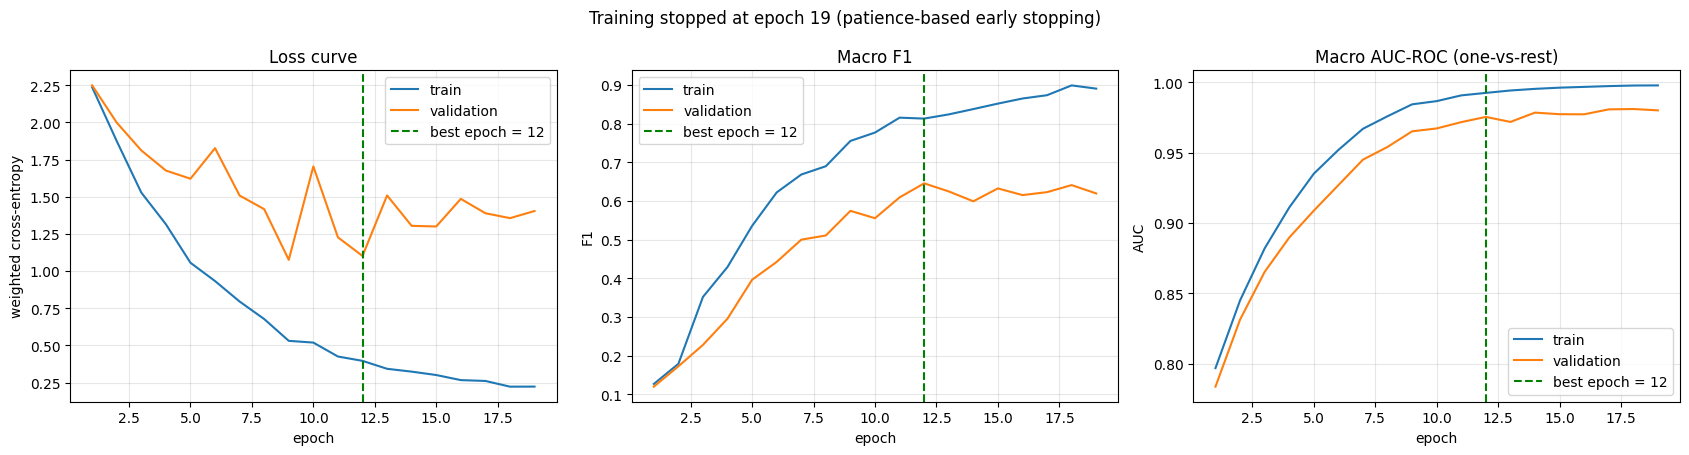

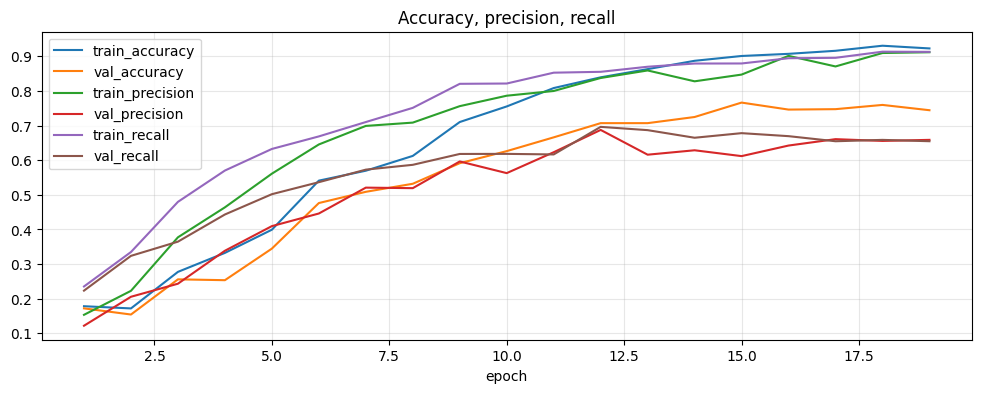

In [14]:
h = history_df
stop_epoch = int(h["epoch"].iloc[-1])
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(h.epoch, h.train_loss, label="train"); ax[0].plot(h.epoch, h.val_loss, label="validation")
ax[0].set_title("Loss curve"); ax[0].set_ylabel("weighted cross-entropy")
ax[1].plot(h.epoch, h.train_f1_macro, label="train")
ax[1].plot(h.epoch, h.val_f1_macro, label="validation")
ax[1].set_title("Macro F1"); ax[1].set_ylabel("F1")
ax[2].plot(h.epoch, h.train_auc_roc, label="train")
ax[2].plot(h.epoch, h.val_auc_roc, label="validation")
ax[2].set_title("Macro AUC-ROC (one-vs-rest)"); ax[2].set_ylabel("AUC")
for a in ax:
    a.axvline(best_epoch, color="green", ls="--", label=f"best epoch = {best_epoch}")
    a.set_xlabel("epoch"); a.grid(alpha=.3); a.legend()
plt.suptitle(f"Training stopped at epoch {stop_epoch} (patience-based early stopping)")
plt.tight_layout(); plt.savefig(FIG / "training_curves.png", dpi=150); plt.show()
h[["epoch", "train_accuracy", "val_accuracy", "train_precision", "val_precision",
    "train_recall", "val_recall"]].plot(x="epoch", figsize=(12, 4), title="Accuracy, precision, recall")
plt.grid(alpha=.3); plt.savefig(FIG / "acc_prec_rec_curves.png", dpi=150); plt.show()


Test set evaluation

TEST: loss 0.9587 acc 0.707 P 0.673 R 0.752 F1 0.691 AUC 0.970
weighted F1: 0.7162
                precision    recall  f1-score   support

        DOMAIN      0.833     0.588     0.690        17
         EMAIL      0.750     1.000     0.857         3
      FILEPATH      0.928     0.889     0.908        72
          IPV4      0.920     1.000     0.958        23
           MD5      0.000     0.000     0.000         8
   REGISTRYKEY      0.600     1.000     0.750         3
          SHA1      0.421     0.364     0.390        22
          SHA2      0.362     0.836     0.505        61
      SOFTWARE      0.770     0.725     0.747       171
          TIME      0.738     0.925     0.821        67
           URL      0.737     0.933     0.824        15
attack-pattern      0.940     0.735     0.825       170
      campaign      0.733     0.786     0.759        14
      identity      0.671     0.760     0.713       150
infrastructure      0.600     1.000     0.750         6
      location      

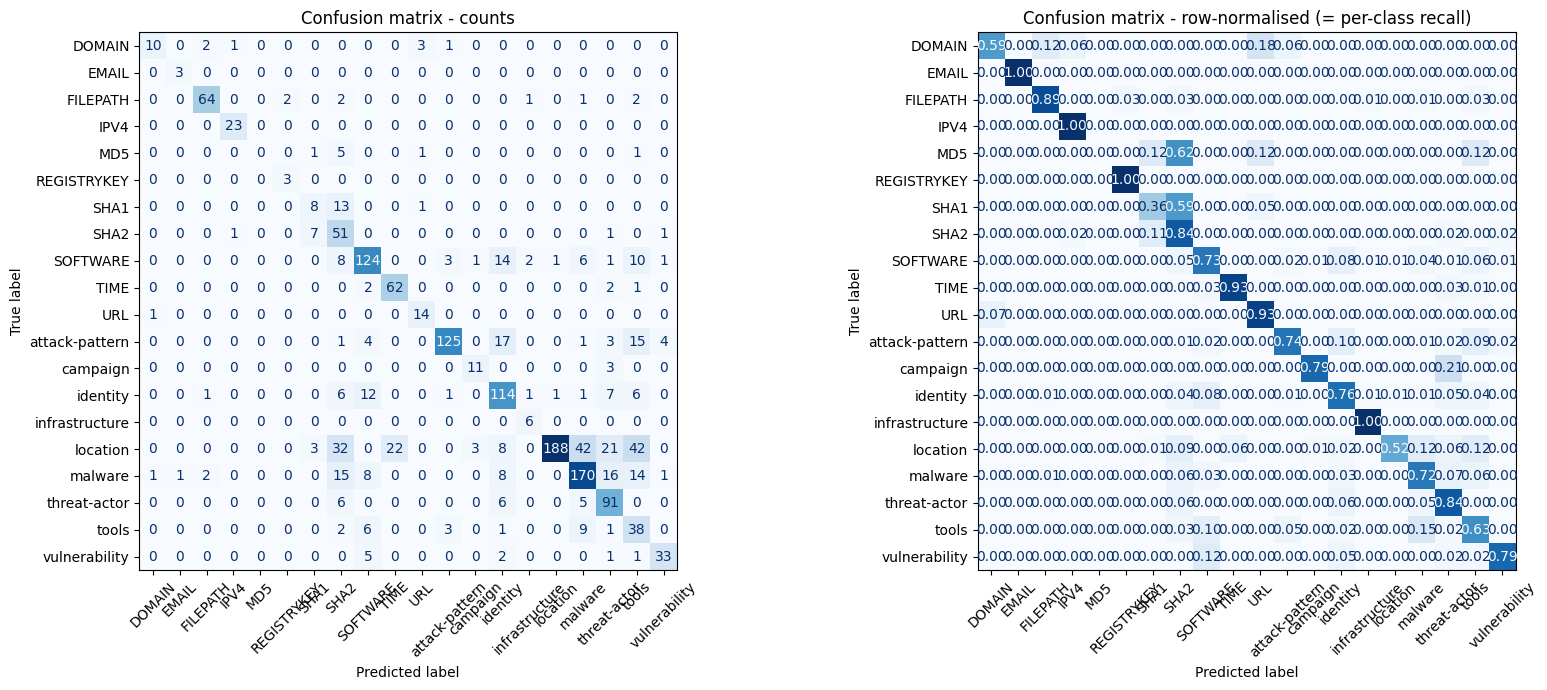

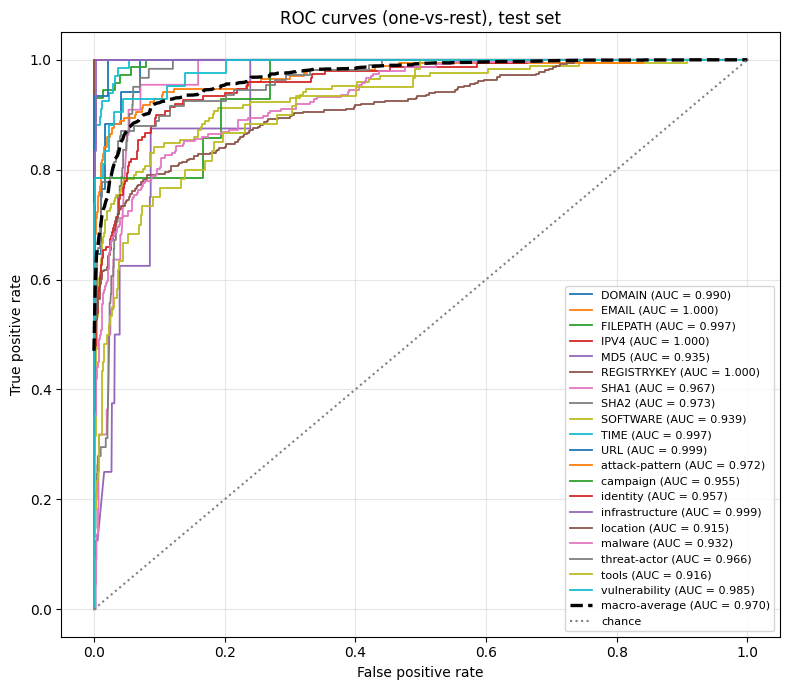

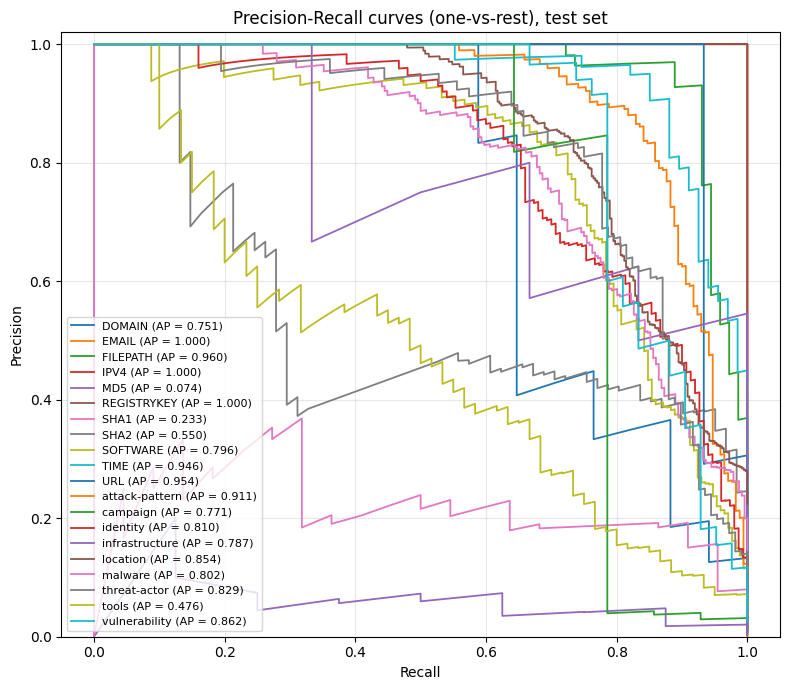

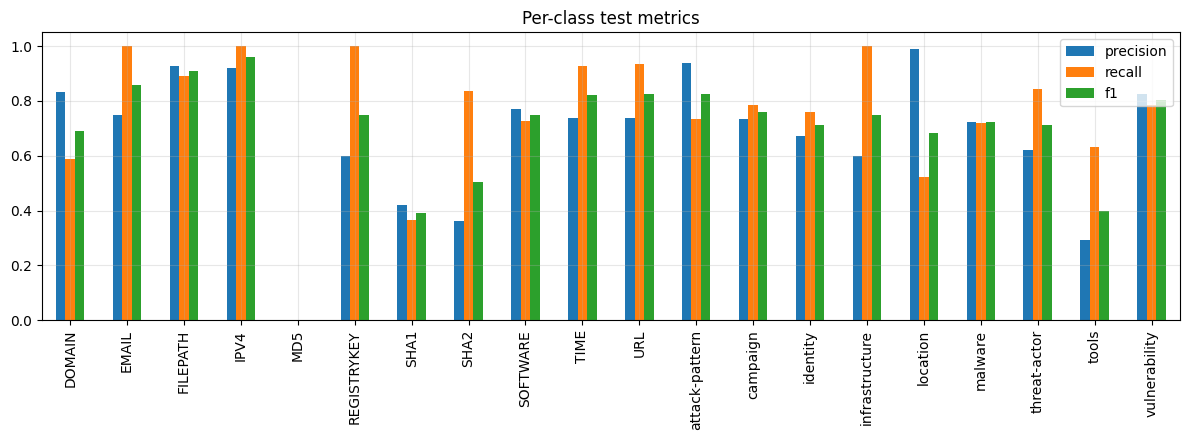

In [15]:
test_m, y_test, p_test = run_eval(model, test_loader)
y_pred = p_test.argmax(1)
print("TEST:", fmt(test_m)); print("weighted F1:",
    round(precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)[2], 4))
print(classification_report(y_test, y_pred, target_names=class_names, digits=3, zero_division=0))
# ---- confusion matrix (counts + row-normalised) ----
cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(1, 2, figsize=(17, 7))
views = [(ax[0], cm, "counts", "d"), (ax[1], cmn, "row-normalised (= per-class recall)", ".2f")]
for a, M, ttl, vf in views:
    ConfusionMatrixDisplay(M, display_labels=class_names).plot(
                            ax=a, cmap="Blues", values_format=vf, xticks_rotation=45, colorbar=False)
    a.set_title(f"Confusion matrix - {ttl}")
plt.tight_layout(); plt.savefig(FIG / "confusion_matrix.png", dpi=150); plt.show()

Y = np.eye(n_classes)[y_test] # one-hot truth for one-vs-rest curves

# ---- ROC curves ----
fig, ax = plt.subplots(figsize=(8, 7))
grid, tprs = np.linspace(0, 1, 500), []
for i, c in enumerate(class_names):
    fpr, tpr, _ = roc_curve(Y[:, i], p_test[:, i])
    ax.plot(fpr, tpr, lw=1.3, label=f"{c} (AUC = {auc(fpr, tpr):.3f})")
    tprs.append(np.interp(grid, fpr, tpr))
macro = np.mean(tprs, axis=0)
ax.plot(grid, macro, "k--", lw=2.4, label=f"macro-average (AUC = {auc(grid, macro):.3f})")
ax.plot([0, 1], [0, 1], ":", color="grey", label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (one-vs-rest), test set")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "roc_curves.png", dpi=150); plt.show()
# ---- Precision-Recall curves ----
fig, ax = plt.subplots(figsize=(8, 7))
for i, c in enumerate(class_names):
    pr, rc, _ = precision_recall_curve(Y[:, i], p_test[:, i])
    ax.plot(rc, pr, lw=1.3, label=f"{c} (AP = {average_precision_score(Y[:, i], p_test[:, i]):.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_ylim(0, 1.02)
ax.set_title("Precision-Recall curves (one-vs-rest), test set")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "pr_curves.png", dpi=150); plt.show()
# ---- per-class precision / recall / F1 ----
P_, R_, F_, S_ = precision_recall_fscore_support(
    y_test, y_pred, labels=range(n_classes), zero_division=0)
pd.DataFrame({"precision": P_, "recall": R_, "f1": F_}, index=class_names).plot.bar(
    figsize=(12, 4.5), title="Per-class test metrics"); plt.ylim(0, 1.05); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "per_class_metrics.png", dpi=150); plt.show()


Baseline coparison

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(train_df["input_text"])
lr_clf = LogisticRegression(max_iter=3000, class_weight="balanced").fit(Xtr, train_df["y"])
p_base = lr_clf.predict_proba(tfidf.transform(test_df["input_text"]))
base_m = compute_metrics(test_df["y"].values, p_base,
                        log_loss(test_df["y"].values, p_base, labels=range(n_classes)))
display(pd.DataFrame({"BiLSTM": test_m, "TF-IDF + LogReg": base_m}).round(4))


,BiLSTM,TF-IDF + LogReg
loss,0.9587,1.5545
accuracy,0.7073,0.7011
precision,0.6726,0.6287
recall,0.7522,0.6558
f1_macro,0.6909,0.6246
auc_roc,0.9697,0.9547


In [17]:
torch.save({"state_dict": model.state_dict(), "config": HP}, ART / "model.pt")
(ART / "preprocess.json").write_text(json.dumps({
    "itos": itos, "max_len": MAX_LEN, "classes": class_names,
    "use_span": USE_SPAN, "context_chars": CONTEXT_CHARS}))
print("saved:", [p.name for p in ART.iterdir()])

saved: ['model.pt', 'preprocess.json']


Explainability

Deployment

Conclusions